Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
insurance.zip: Skipping, found more recently modified local copy (use --force to force download)
['insurance.csv']
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 

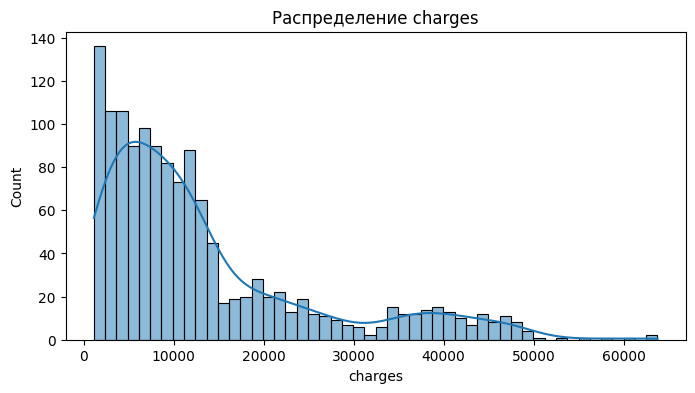


Размер обучающей выборки: (1070, 6)
Размер тестовой выборки: (268, 6)


In [ ]:
# Загрузка данных
import pandas as pd
import os
import shutil
from google.colab import files
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()

!kaggle datasets download -d mirichoi0218/insurance

with zipfile.ZipFile('insurance.zip', 'r') as zip_ref:
    zip_ref.extractall('insurance')
# Показать файлы в директории
print(os.listdir('insurance'))

df = pd.read_csv('insurance/insurance.csv')
# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())

# Проверим распределение целевой переменной
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title('Распределение charges')
plt.show()

# Предобработка данных
# Категориальные признаки
categorical_features = ['sex', 'smoker', 'region']
# Числовые признаки
numeric_features = ['age', 'bmi', 'children']

# Создаем препроцессор: OneHotEncoder для категориальных, StandardScaler для числовых
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # drop='first' для избежания мультиколлинеарности
    ])

# Целевая переменная
X = df.drop('charges', axis=1)
y = df['charges']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Linear Regression: MAE=4181.19, RMSE=5796.28, R2=0.7836


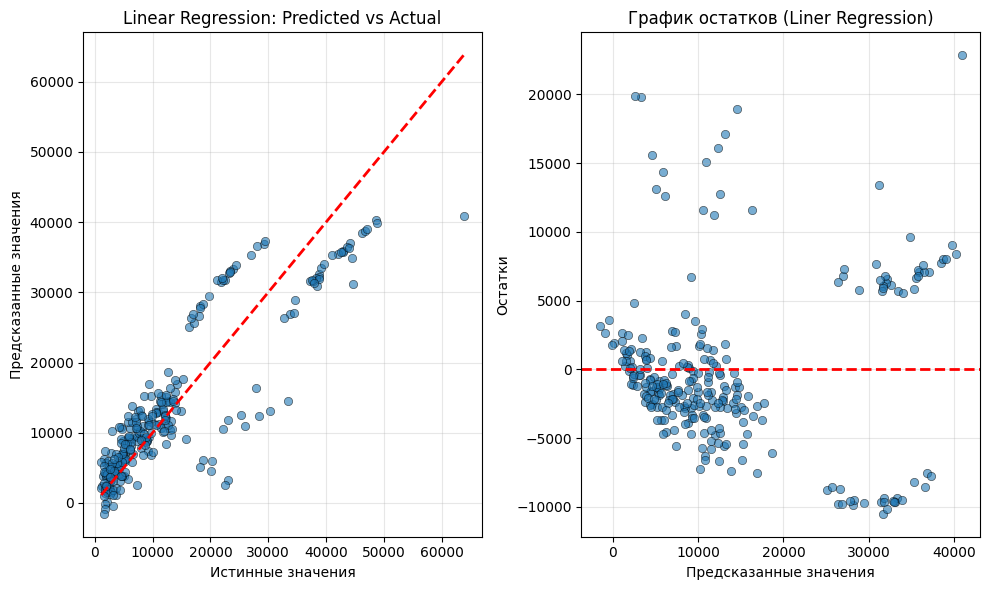

In [23]:
# 1. Линейная регрессия (LinearRegression)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Оценка модели
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results = []
    results.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })
    print(f"{model_name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")
    return y_pred

# Создаем и обучаем модель
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])

# Оценка модели и получение предсказаний
y_pred_lr = evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, "Linear Regression")

# Визуализируем результаты
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr, edgecolors='k', alpha=0.6, linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Linear Regression: Predicted vs Actual')
plt.grid (True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals, edgecolors='k', alpha=0.6, linewidths=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Liner Regression)')
plt.grid (True, alpha=0.3)

plt.tight_layout()
plt.show()

Лучший alpha для Ridge: {'regressor__alpha': 1.0}
Ridge: MAE=4193.20, RMSE=5800.46, R2=0.7833


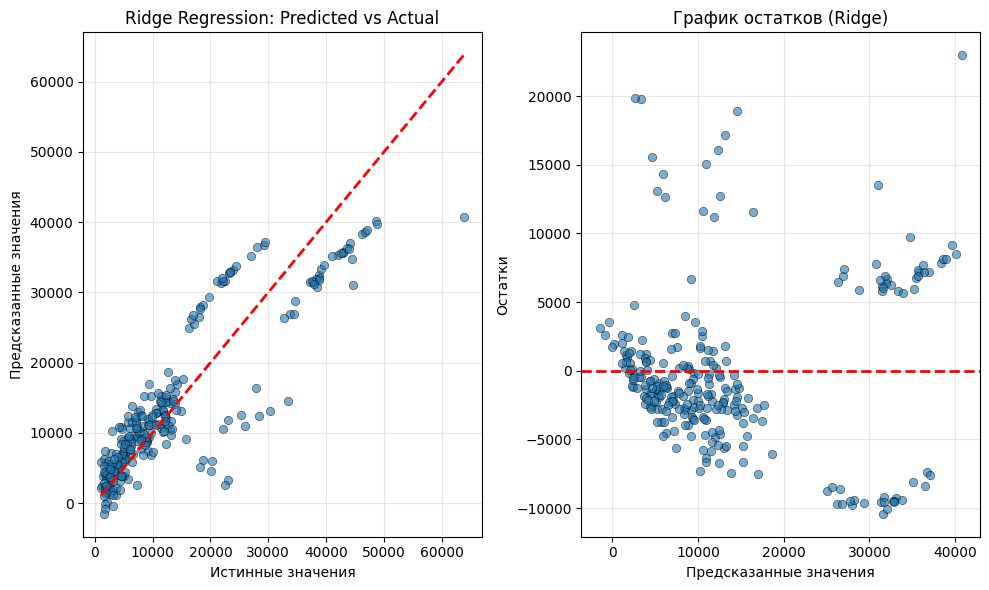

In [25]:
# 2. Гребневая регрессия (Ridge)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Препроцессор и гребневая регрессия
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', Ridge(random_state=42))])
# Задаем сетку параметров для alpha
param_grid_ridge = {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}

# GridSearchCV с 5-кратной кросс-валидацией
grid_ridge = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

print(f"Лучший alpha для Ridge: {grid_ridge.best_params_}")
# Получаем предсказания лучшей модели
best_ridge = grid_ridge.best_estimator_

# Оценка модели и получение предсказаний
y_pred_ridge = evaluate_model(best_ridge, X_train, y_train, X_test, y_test, "Ridge")

# Визуализируем результаты
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_ridge, edgecolors='k', alpha=0.6, linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Ridge Regression: Predicted vs Actual')
plt.grid (True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals_ridge = y_test - y_pred_ridge
plt.scatter(y_pred_ridge, residuals_ridge, edgecolors='k', alpha=0.6, linewidths=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Ridge)')
plt.grid (True, alpha=0.3)

plt.tight_layout()
plt.show()


Подбор параметров для RandomForest с GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры RandomForest: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
RandomForest: MAE=2476.62, RMSE=4425.21, R2=0.8739


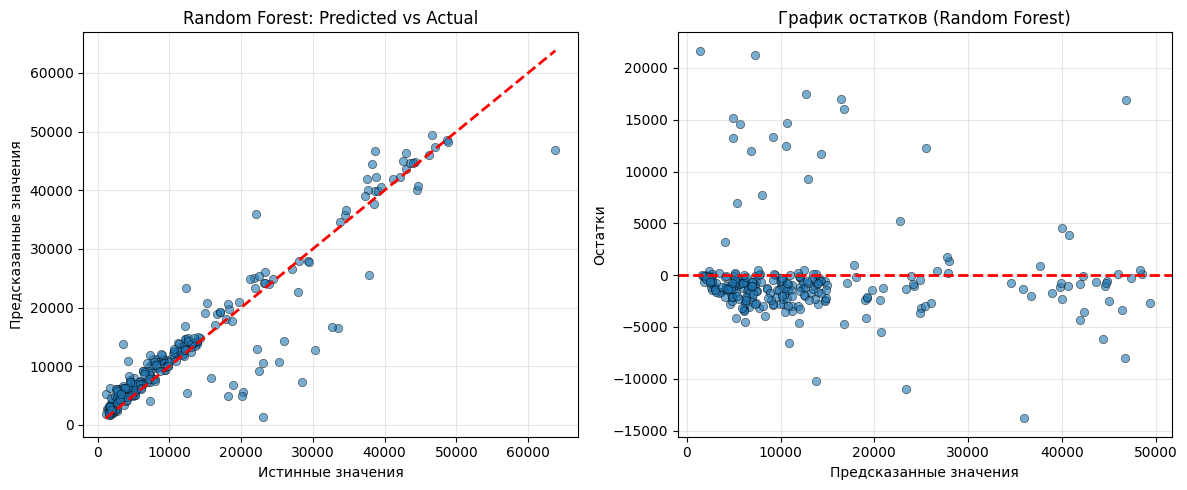

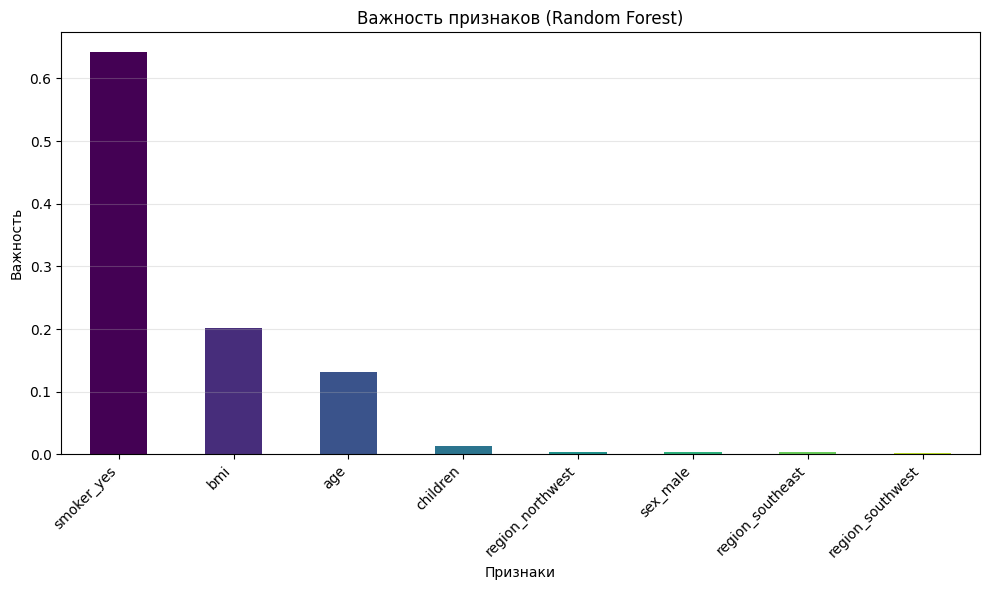

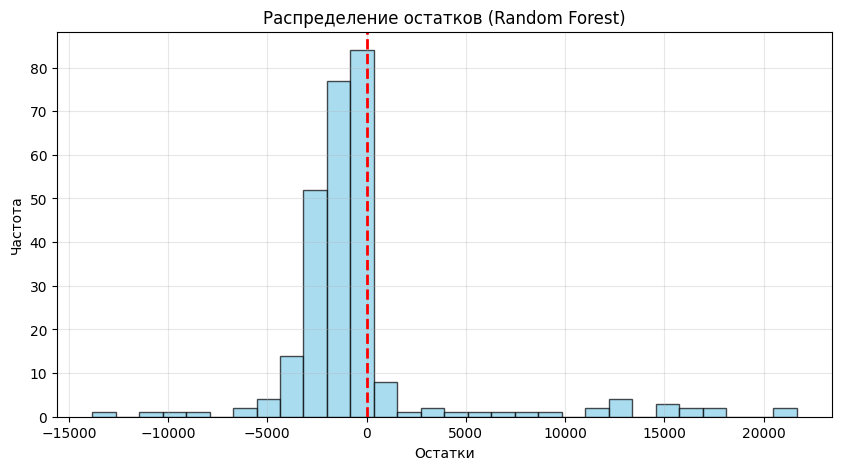


Топ-5 лучших комбинаций параметров:
                                                                                                                           params  mean_test_score  std_test_score
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}    -2.316674e+07    4.895326e+06
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}    -2.322867e+07    4.903683e+06
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}    -2.326428e+07    4.860297e+06
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}    -2.327575e+07    4.947669e+06
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}    -2.333880e+07  

In [28]:
# 3 Случайный лес (RandomForest)
from sklearn.ensemble import RandomForestRegressor

# Для случайного леса предобработка не обязательна, но кодирование категорий нужно.
# Создадим отдельный пайплайн только с кодировщиком (без масштабирования).
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # числовые оставляем как есть
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_rf),
                               ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Сетка параметров для Случайного леса
param_grid_rf = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
    }

# GridSearchCV с 5-кратной кросс-валидацией
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('Подбор параметров для RandomForest с GridSearchCV...')
grid_rf.fit(X_train, y_train)

print(f"Лучшие параметры RandomForest: {grid_rf.best_params_}")
best_rf = grid_rf.best_estimator_

# Оценка модели и получение предсказаний
y_pred_rf = evaluate_model(best_rf, X_train, y_train, X_test, y_test, "RandomForest")

# Визуализация

# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Random Forest: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_rf = y_test - y_pred_rf
plt.scatter(y_pred_rf, residuals_rf, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Random Forest)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
# Получаем имена признаков после трансформации
feature_names = (numeric_features +
                 list(best_rf.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Важности из лучшей модели
importances = best_rf.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_rf, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (Random Forest)')
plt.grid(True, alpha=0.3)
plt.show()

# Сравнение результатов GridSearch
results_rf = pd.DataFrame(grid_rf.cv_results_)
top_results = results_rf.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\nТоп-5 лучших комбинаций параметров:")
print(top_results.to_string(index=False))

Подбор параметров для GradientBoosting с GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры GradientBoosting: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}
Fitting 5 folds for each of 72 candidates, totalling 360 fits
GradientBoosting: MAE=2521.06, RMSE=4349.26, R2=0.8782


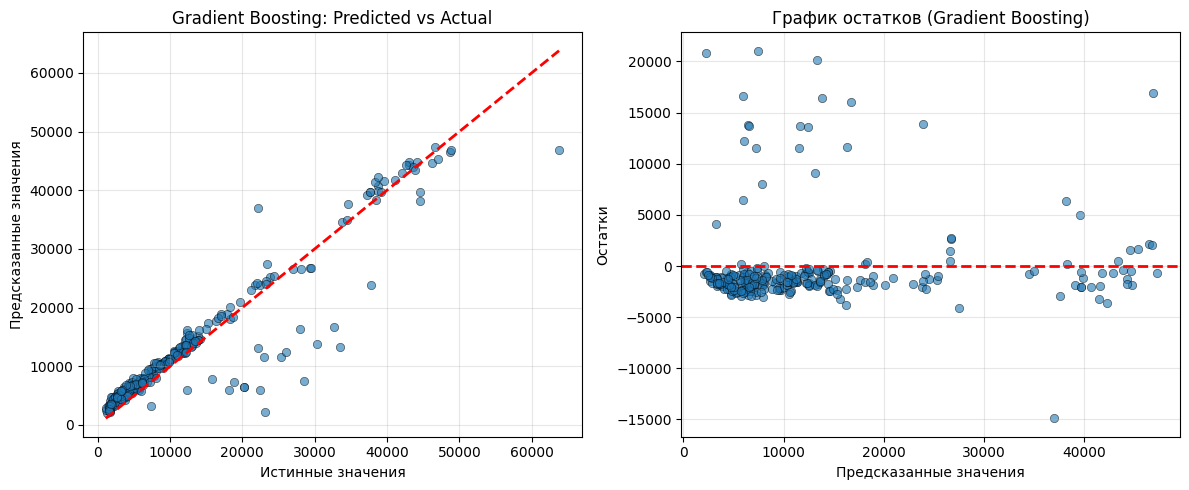

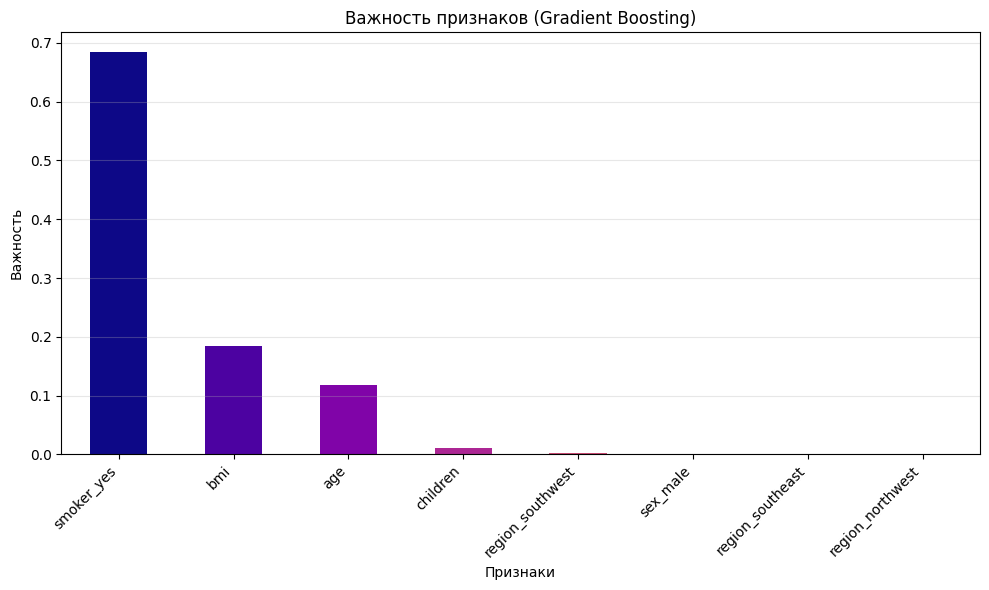

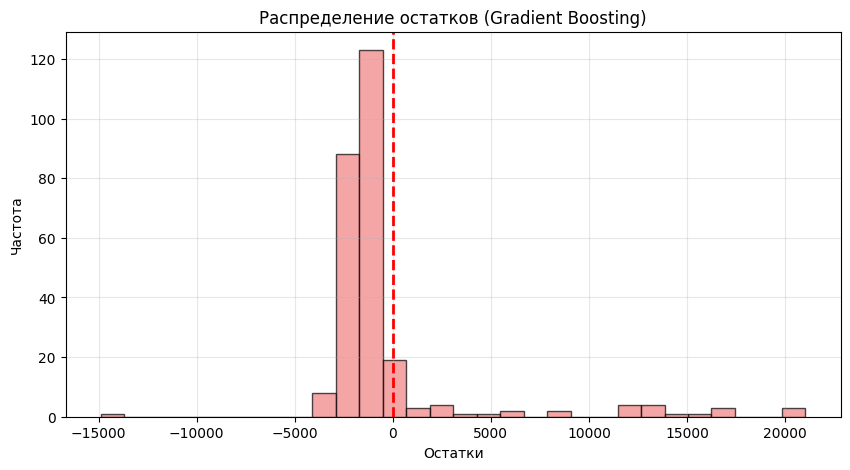

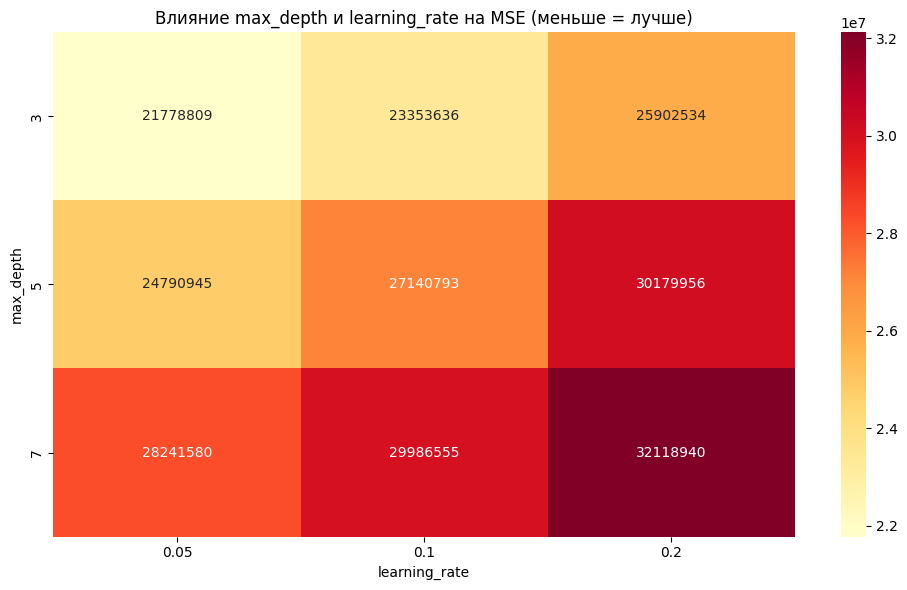


 Топ-5 лучших комбинаций параметров Gradient Boosting:
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8} | MSE: 21349200 ± 4827299
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8} | MSE: 21373783 ± 4838510
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0} | MSE: 21523588 ± 4930629
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0} | MSE: 21577099 ± 4934957
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8} | MSE: 22037579 ± 4740706


In [31]:
# 4. Градиентный бустинг (GradientBoosting)
from sklearn.ensemble import GradientBoostingRegressor

# Создаем препроцессор (только кодирование, масштабирование не требуется)
preprocessor_gb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # числовые оставляем как есть
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Пайплайн с препроцессором и градиентным бустингом
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_gb),
                               ('regressor', GradientBoostingRegressor(random_state=42))])

# Сетка параметров для GridSearchCV
param_grid_gb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0],
    'regressor__min_samples_split': [2, 5]
}

# GridSearchCV с 5-кратной кросс-валидацией
grid_gb = GridSearchCV(gb_pipeline, param_grid_gb, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('Подбор параметров для GradientBoosting с GridSearchCV...')
grid_gb.fit(X_train, y_train)

print(f"Лучшие параметры GradientBoosting: {grid_gb.best_params_}")
best_gb = grid_gb.best_estimator_

# Оценка модели и получение предсказаний
y_pred_gb = evaluate_model(grid_gb, X_train, y_train, X_test, y_test, "GradientBoosting")

# Визуализация

# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_gb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Gradient Boosting: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_gb = y_test - y_pred_gb
plt.scatter(y_pred_gb, residuals_gb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Gradient Boosting)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
feature_names = (numeric_features +
                 list(best_gb.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = best_gb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_gb, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (Gradient Boosting)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта для визуализации влияния параметров
# (агрегируем результаты GridSearch)
results_gb = pd.DataFrame(grid_gb.cv_results_)

# Создаём сводную таблицу для heatmap
pivot_table = results_gb.pivot_table(
    values='mean_test_score',
    index='param_regressor__max_depth',
    columns='param_regressor__learning_rate',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_table, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=pivot_table.columns, yticklabels=pivot_table.index)
plt.title('Влияние max_depth и learning_rate на MSE (меньше = лучше)')
plt.xlabel('learning_rate')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Сравнение top-5 лучших комбинаций
top_results_gb = results_gb.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score']
]
print("\n Топ-5 лучших комбинаций параметров Gradient Boosting:")
for i, row in top_results_gb.iterrows():
    print(f"  {row['params']} | MSE: {-row['mean_test_score']:.0f} ± {row['std_test_score']:.0f}")

Подбор параметров для XGBoost с GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры XGBoost: {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0}
XGBoost: MAE=2452.99, RMSE=4236.27, R2=0.8844


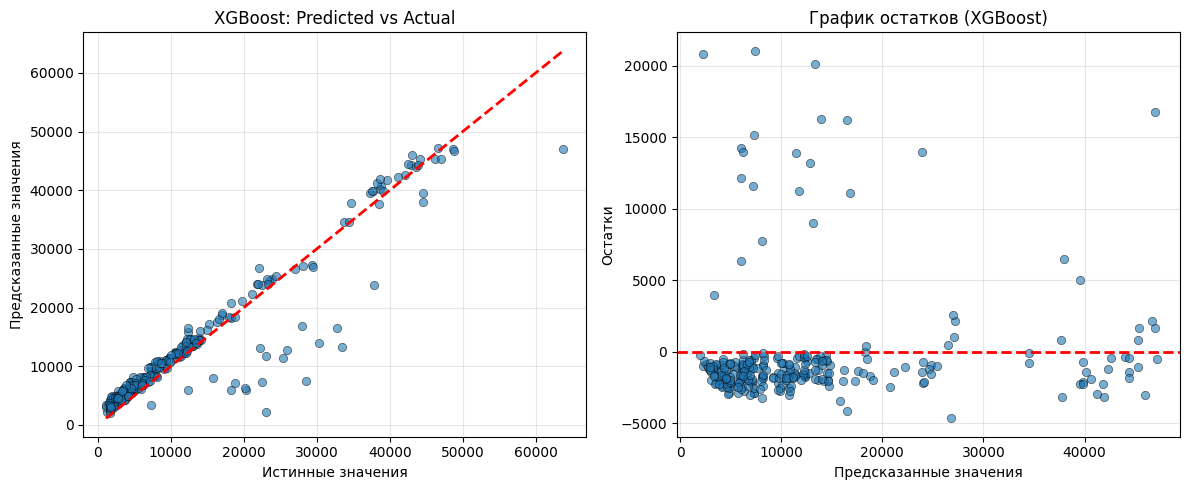

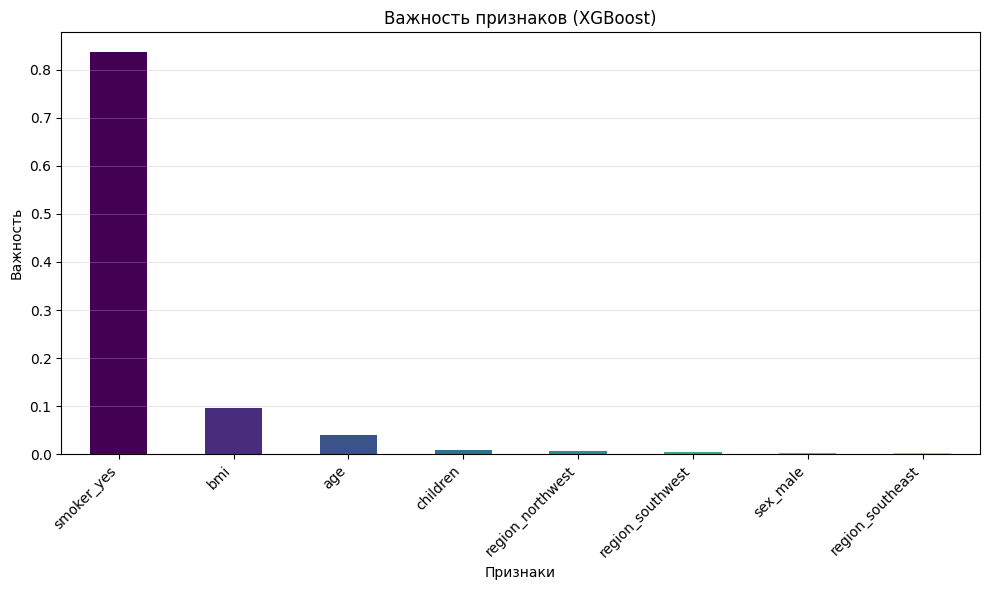

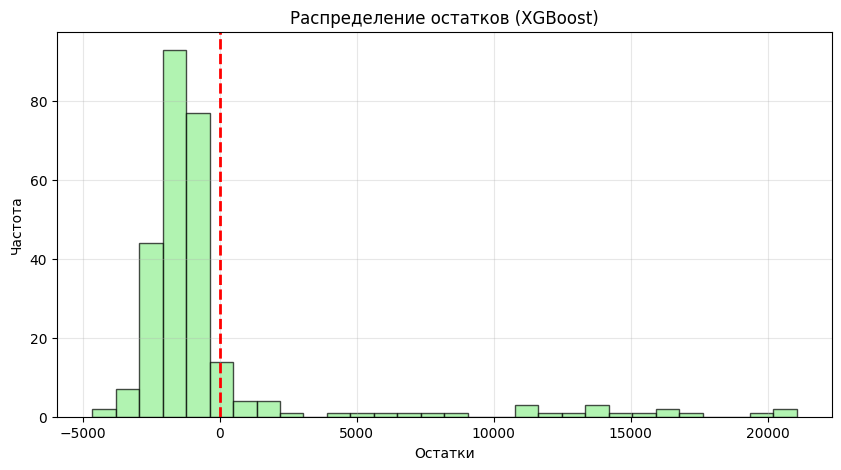

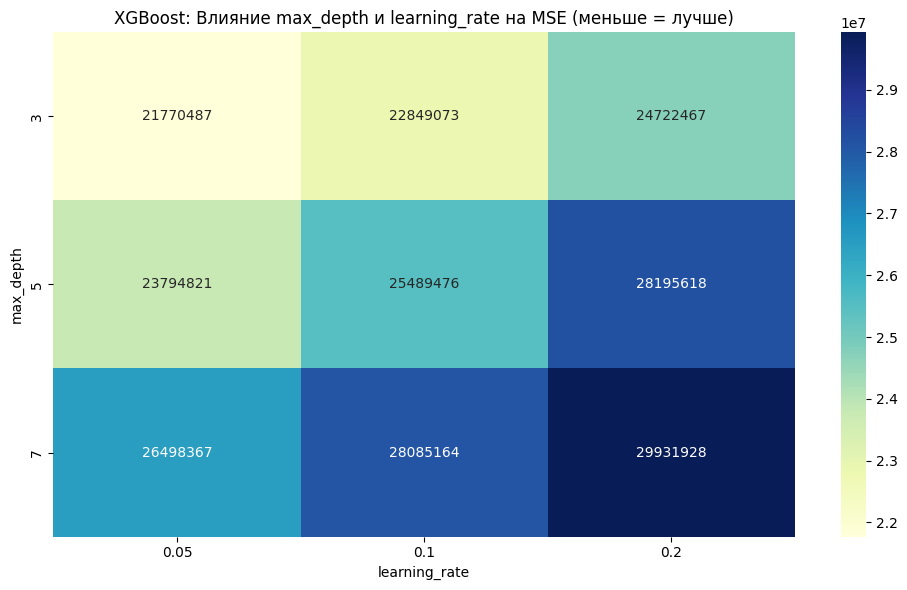

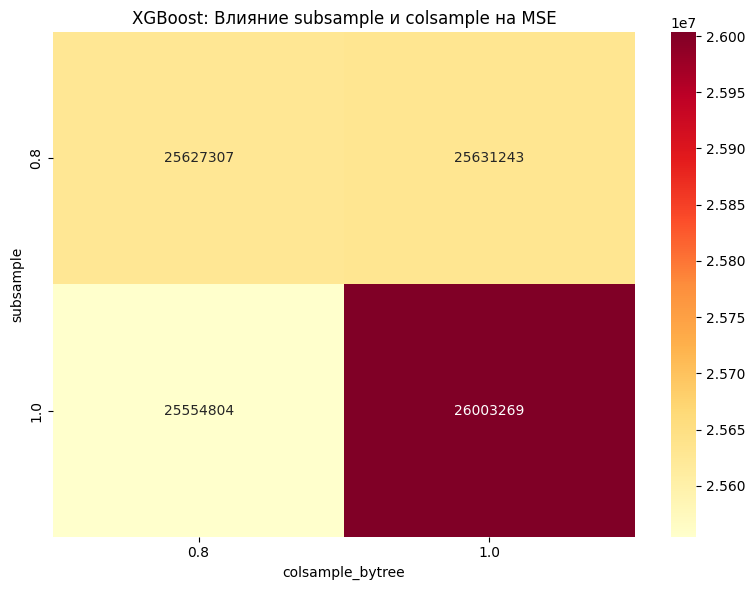


 Топ-10 лучших комбинаций параметров XGBoost:
                                                                                                                                                        params          MSE  std_test_score
{'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0} 2.140699e+07    4.683842e+06
{'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8} 2.141823e+07    4.563305e+06
{'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8} 2.152201e+07    4.716870e+06
{'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0} 2.159378e+07    4.623683e+06
{'regressor__

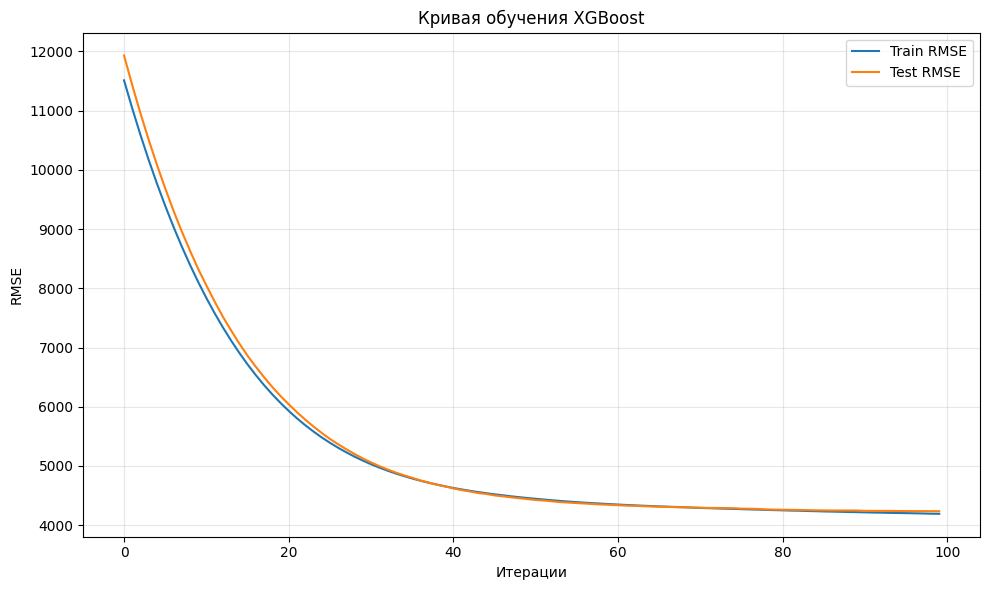

In [34]:
# 5. XGBoost
import xgboost as xgb

# Создаем препроцессор (только кодирование, масштабирование не требуется)
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # числовые оставляем как есть
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Пайплайн с препроцессором и XGBoost
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_xgb),
                                ('regressor', xgb.XGBRegressor(random_state=42, verbosity=0))])

# Сетка параметров для GridSearchCV
param_grid_xgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

# GridSearchCV с 5-кратной кросс-валидацией
grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5,
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

print('Подбор параметров для XGBoost с GridSearchCV...')
grid_xgb.fit(X_train, y_train)

print(f"Лучшие параметры XGBoost: {grid_xgb.best_params_}")
best_xgb = grid_xgb.best_estimator_

# Оценка модели и получение предсказаний
y_pred_xgb = evaluate_model(best_xgb, X_train, y_train, X_test, y_test, "XGBoost")

# Визуализация
# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('XGBoost: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_xgb = y_test - y_pred_xgb
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (XGBoost)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
feature_names = (numeric_features +
                 list(best_xgb.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = best_xgb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (XGBoost)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_xgb, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (XGBoost)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта для визуализации влияния параметров
results_xgb = pd.DataFrame(grid_xgb.cv_results_)

# Создаём сводную таблицу для heatmap (max_depth vs learning_rate)
pivot_lr_depth = results_xgb.pivot_table(
    values='mean_test_score',
    index='param_regressor__max_depth',
    columns='param_regressor__learning_rate',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_lr_depth, annot=True, fmt='.0f', cmap='YlGnBu',
            xticklabels=pivot_lr_depth.columns, yticklabels=pivot_lr_depth.index)
plt.title('XGBoost: Влияние max_depth и learning_rate на MSE (меньше = лучше)')
plt.xlabel('learning_rate')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Влияние subsample и colsample
pivot_sample = results_xgb.pivot_table(
    values='mean_test_score',
    index='param_regressor__subsample',
    columns='param_regressor__colsample_bytree',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(-pivot_sample, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=pivot_sample.columns, yticklabels=pivot_sample.index)
plt.title('XGBoost: Влияние subsample и colsample на MSE')
plt.xlabel('colsample_bytree')
plt.ylabel('subsample')
plt.tight_layout()
plt.show()

# Сравнение топ-10 лучших комбинаций
top_results_xgb = results_xgb.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score']
].copy()
top_results_xgb['mean_test_score'] = -top_results_xgb['mean_test_score']
top_results_xgb = top_results_xgb.rename(columns={'mean_test_score': 'MSE'})

print("\n Топ-10 лучших комбинаций параметров XGBoost:")
print(top_results_xgb.to_string(index=False))

# График сходимости (для лучшей модели)
# Получаем историю обучения (только если использовали early_stopping)
try:
    # Обучаем ещё раз с evals_result для получения истории
    eval_set = [(X_train, y_train), (X_test, y_test)]
    xgb_model = best_xgb.named_steps['regressor']
    xgb_model.fit(
        best_xgb.named_steps['preprocessor'].transform(X_train),
        y_train,
        eval_set=[(best_xgb.named_steps['preprocessor'].transform(X_train), y_train),
                  (best_xgb.named_steps['preprocessor'].transform(X_test), y_test)],
        verbose=False
    )

    # Получаем историю
    results = xgb_model.evals_result()

    plt.figure(figsize=(10, 6))
    epochs = len(results['validation_0']['rmse'])
    x_axis = range(0, epochs)

    plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
    plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
    plt.xlabel('Итерации')
    plt.ylabel('RMSE')
    plt.title('Кривая обучения XGBoost')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except:
    print("(Кривая обучения недоступна - требуется обучение с eval_set)")

Подбор параметров для LGBM с GridSearchCV ...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Лучшие параметры LightGBM: {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__n_estimators': 100, 'regressor__num_leaves': 31, 'regressor__subsample': 0.8}
LightGBM: MAE=2415.49, RMSE=4288.47, R2=0.8815


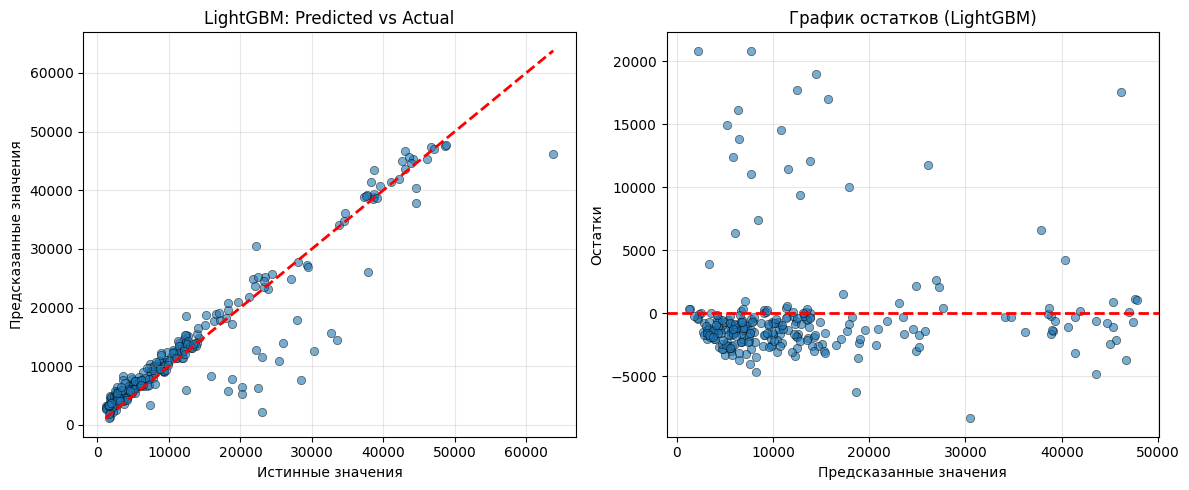

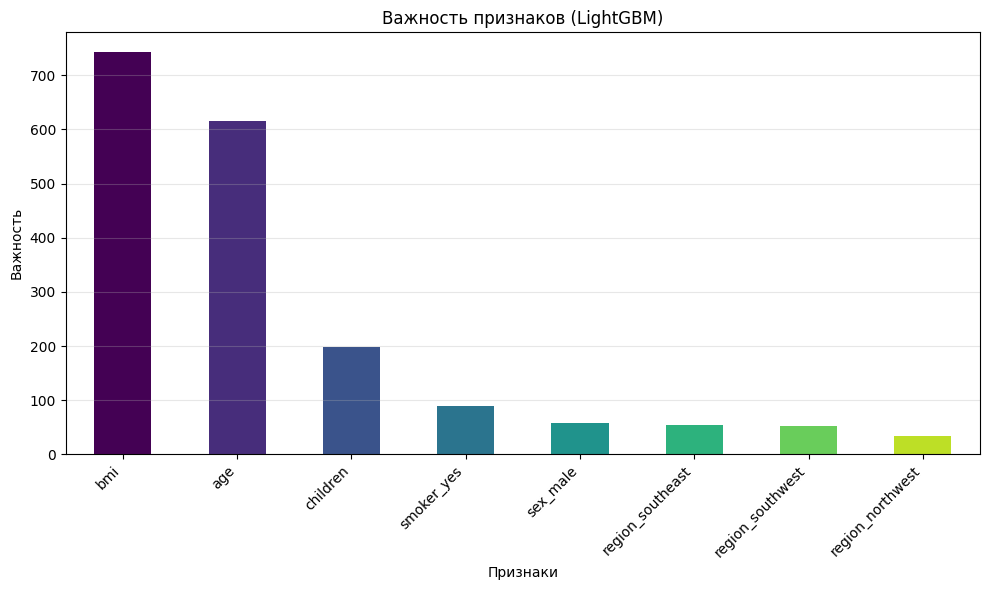

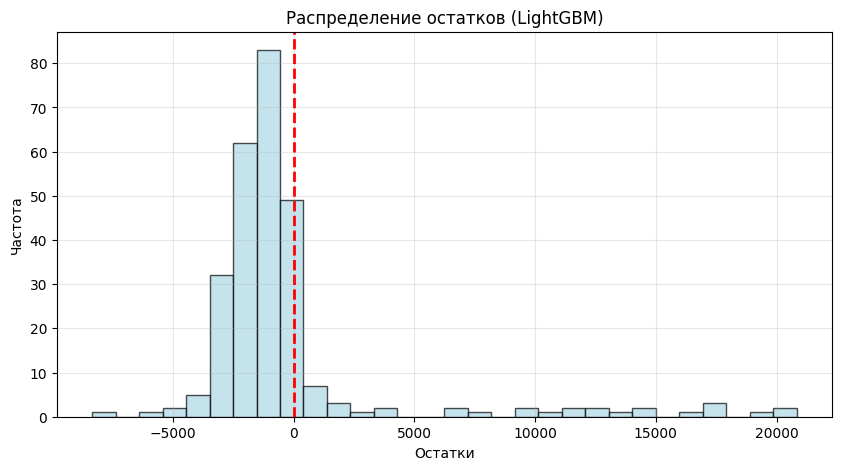

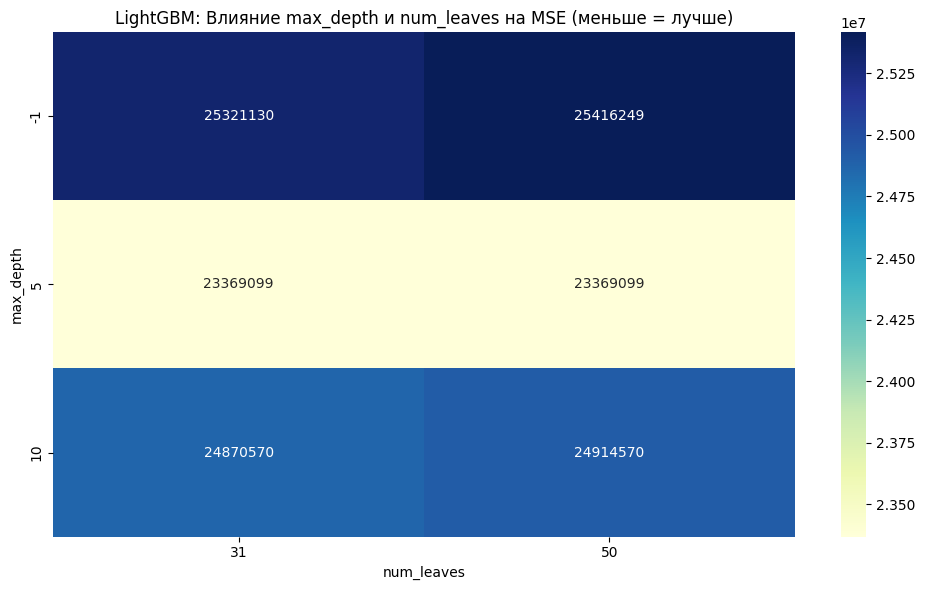

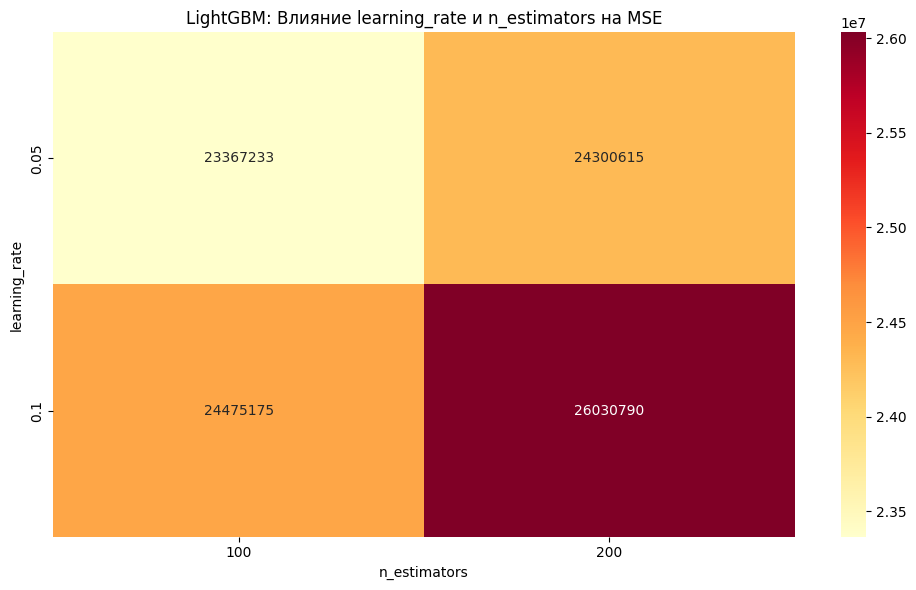


 Топ-10 лучших комбинаций параметров LightGBM:
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8} | MSE: 22189834 ± 4916054
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 1.0} | MSE: 22189834 ± 4916054
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.8} | MSE: 22189834 ± 4916054
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 1.0} | MSE: 22189834 ± 4916054
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8} | MSE: 23085299 ± 4891902
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 1.0} | MSE: 23085299 ± 4891902
  {'colsample_bytree': 1.0, 'learning_rate': 0.05, '

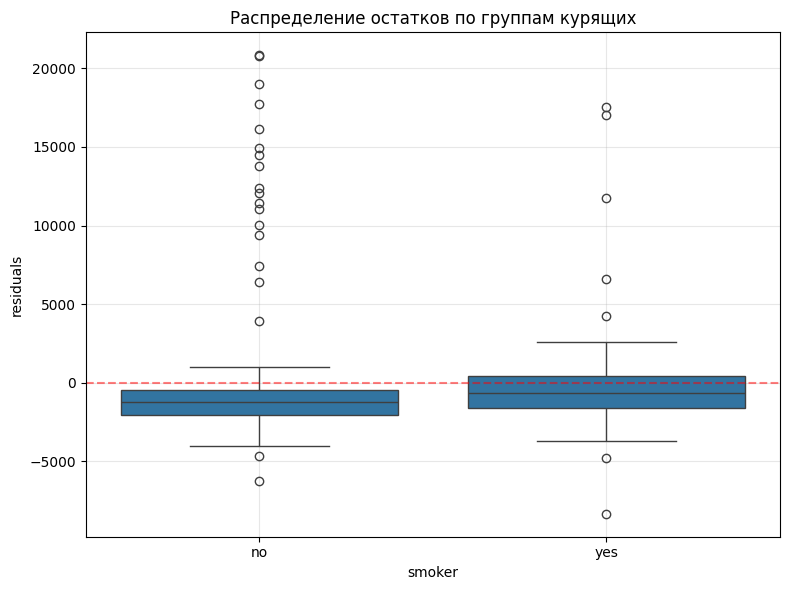

In [46]:
# 6. Регрессор LGBM
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Создаем препроцессор (только кодирование, масштабирование не требуется)
preprocessor_lgb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # числовые оставляем как есть
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Пайплайн с препроцессором и LGBM
lgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_lgb),
                                ('regressor', lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1))])

# Сетка параметров для GridSearchCV
param_grid_lgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [5, 10, -1],  # -1 означает без ограничения
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__num_leaves': [31, 50],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

#  GridSearchCV с 5-кратной кросс-валидацией
grid_lgb = GridSearchCV(lgb_pipeline, param_grid_lgb, cv=5,
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

print('Подбор параметров для LGBM с GridSearchCV ...')
grid_lgb.fit(X_train, y_train)

print(f"Лучшие параметры LightGBM: {grid_lgb.best_params_}")
best_lgb = grid_lgb.best_estimator_

# Оценка модели и получение предсказаний
y_pred_lgb = evaluate_model(best_lgb, X_train, y_train, X_test, y_test, "LightGBM")

# Визуализация
# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('LightGBM: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_lgb = y_test - y_pred_lgb
plt.scatter(y_pred_lgb, residuals_lgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (LightGBM)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
feature_names = (numeric_features +
                 list(best_lgb.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = best_lgb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (LightGBM)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_lgb, bins=30, edgecolor='black', alpha=0.7, color='lightblue')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (LightGBM)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта: max_depth vs num_leaves
results_lgb = pd.DataFrame(grid_lgb.cv_results_)

# Pivot table для визуализации влияния параметров
pivot_depth_leaves = results_lgb.pivot_table(
    values='mean_test_score',
    index='param_regressor__max_depth',
    columns='param_regressor__num_leaves',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_depth_leaves, annot=True, fmt='.0f', cmap='YlGnBu',
            xticklabels=pivot_depth_leaves.columns, yticklabels=pivot_depth_leaves.index)
plt.title('LightGBM: Влияние max_depth и num_leaves на MSE (меньше = лучше)')
plt.xlabel('num_leaves')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Влияние learning_rate и n_estimators
pivot_lr_estimators = results_lgb.pivot_table(
    values='mean_test_score',
    index='param_regressor__learning_rate',
    columns='param_regressor__n_estimators',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_lr_estimators, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=pivot_lr_estimators.columns, yticklabels=pivot_lr_estimators.index)
plt.title('LightGBM: Влияние learning_rate и n_estimators на MSE')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.tight_layout()
plt.show()

# Сравнение топ-10 лучших комбинаций
top_results_lgb = results_lgb.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score']
].copy()
top_results_lgb['mean_test_score'] = -top_results_lgb['mean_test_score']
top_results_lgb = top_results_lgb.rename(columns={'mean_test_score': 'MSE'})

print("\n Топ-10 лучших комбинаций параметров LightGBM:")
for i, row in top_results_lgb.iterrows():
    params_str = str(row['params']).replace('regressor__', '')
    print(f"  {params_str} | MSE: {row['MSE']:.0f} ± {row['std_test_score']:.0f}")

# Кривая обучения (для лучшей модели)
try:
    # Обучаем ещё раз с историей
    lgb_model = best_lgb.named_steps['regressor']
    X_train_transformed = best_lgb.named_steps['preprocessor'].transform(X_train)
    X_test_transformed = best_lgb.named_steps['preprocessor'].transform(X_test)

    # Создаем datasets для валидации
    train_data = lgb.Dataset(X_train_transformed, label=y_train)
    valid_data = lgb.Dataset(X_test_transformed, label=y_test, reference=train_data)

    # Параметры из лучшей модели
    params = lgb_model.get_params()
    params['verbose'] = -1

    # Обучаем с логами
    evals_result = {}
    lgb_model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        valid_names=['train', 'eval'],
        num_boost_round=params['n_estimators'],
        callbacks=[lgb.record_evaluation(evals_result)],
        verbose_eval=False
    )

    # График сходимости
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.plot(evals_result['train']['rmse'], label='Train RMSE', color='blue')
    ax.plot(evals_result['eval']['rmse'], label='Validation RMSE', color='red')
    plt.xlabel('Итерации')
    plt.ylabel('RMSE')
    plt.title('Кривая обучения LightGBM')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(Кривая обучения недоступна: {e}")

# Диаграмма размаха для остатков по группам (опционально)
# Добавляем предсказания в исходный DataFrame для анализа
X_test_with_pred = X_test.copy()
X_test_with_pred['predicted'] = y_pred_lgb
X_test_with_pred['residuals'] = residuals_lgb
X_test_with_pred['smoker'] = X_test['smoker']  # если есть в данных

# Боксплот остатков для курящих и некурящих
if 'smoker' in X_test.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='smoker', y='residuals', data=X_test_with_pred)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.title('Распределение остатков по группам курящих')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


  Linear Regression: MAE=4181.19, RMSE=5796.28, R2=0.7836
  Ridge: MAE=4193.20, RMSE=5800.46, R2=0.7833
  Random Forest: MAE=2476.62, RMSE=4425.21, R2=0.8739
  Gradient Boosting: MAE=2521.06, RMSE=4349.26, R2=0.8782
  XGBoost: MAE=2452.99, RMSE=4236.27, R2=0.8844
  LightGBM: MAE=2415.49, RMSE=4288.47, R2=0.8815


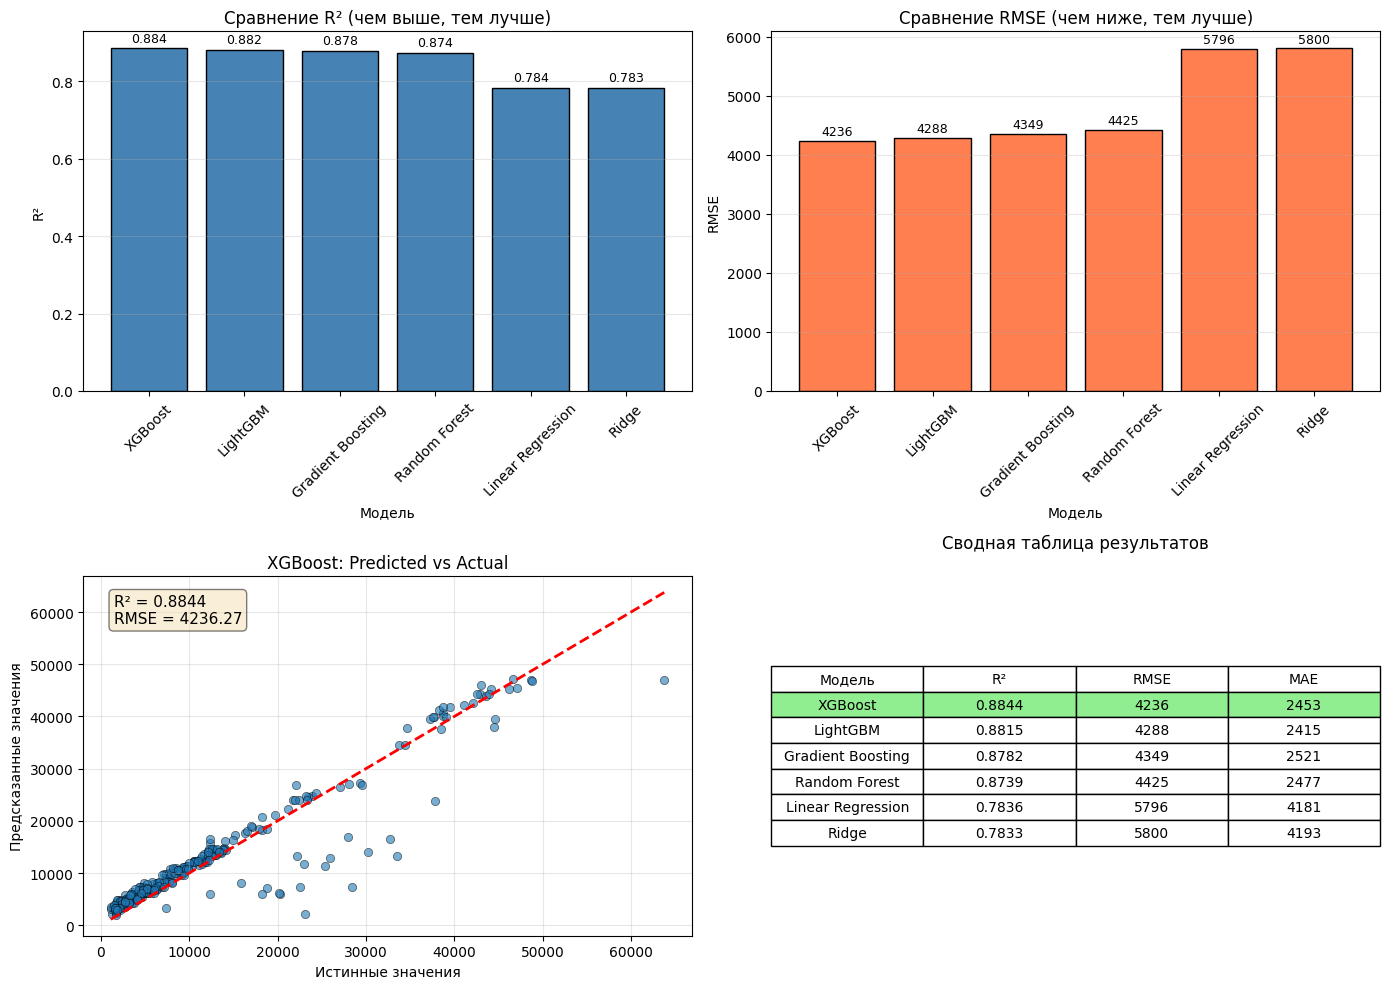


ЛУЧШАЯ МОДЕЛЬ
   XGBoost: R² = 0.8844, RMSE = 4236.27, MAE = 2452.99

 Рейтинг моделей:
   1st 1. XGBoost: R²=0.8844
   2nd 2. LightGBM: R²=0.8815
   3rd 3. Gradient Boosting: R²=0.8782
      4. Random Forest: R²=0.8739
      5. Linear Regression: R²=0.7836
      6. Ridge: R²=0.7833

 Результаты сохранены в 'model_comparison.csv'


In [45]:
# Сравнение моделей и выбор лучшей
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Список для результатов
results = []

# Функция для добавления результатов
def add_result(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"  {name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

# Добавляем результаты всех обученных моделей
models_to_check = [
    ('Linear Regression', 'y_pred_lr'),
    ('Ridge', 'y_pred_ridge'),
    ('Random Forest', 'y_pred_rf'),
    ('Gradient Boosting', 'y_pred_gb'),
    ('XGBoost', 'y_pred_xgb'),
    ('LightGBM', 'y_pred_lgb')
]

for name, var_name in models_to_check:
    try:
        y_pred = eval(var_name)
        add_result(name, y_test, y_pred)
    except NameError:
        print(f" {name} не найдена")

# Создаем DataFrame и сортируем
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Сравнение R²
ax = axes[0, 0]
bars = ax.bar(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='black')
ax.set_xlabel('Модель')
ax.set_ylabel('R²')
ax.set_title('Сравнение R² (чем выше, тем лучше)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, results_df['R2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Сравнение RMSE
ax = axes[0, 1]
bars = ax.bar(results_df['Model'], results_df['RMSE'], color='coral', edgecolor='black')
ax.set_xlabel('Модель')
ax.set_ylabel('RMSE')
ax.set_title('Сравнение RMSE (чем ниже, тем лучше)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, results_df['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# 3. Лучшая модель - Predicted vs Actual
best_model = results_df.iloc[0]['Model']
best_pred = None
for name, var_name in models_to_check:
    if name == best_model:
        try:
            best_pred = eval(var_name)
        except NameError:
            pass

ax = axes[1, 0]
if best_pred is not None:
    ax.scatter(y_test, best_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Истинные значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{best_model}: Predicted vs Actual')
    ax.grid(True, alpha=0.3)

    # Добавляем метрики на график
    r2 = results_df.iloc[0]['R2']
    rmse = results_df.iloc[0]['RMSE']
    ax.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.2f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Таблица результатов
ax = axes[1, 1]
ax.axis('off')
ax.axis('tight')

# Создаем таблицу
table_data = []
for i, row in results_df.iterrows():
    table_data.append([row['Model'], f"{row['R2']:.4f}", f"{row['RMSE']:.0f}", f"{row['MAE']:.0f}"])

table = ax.table(cellText=table_data,
                 colLabels=['Модель', 'R²', 'RMSE', 'MAE'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Выделяем лучшую строку
for j in range(4):
    table[(1, j)].set_facecolor('#90EE90')  # светло-зеленый

ax.set_title('Сводная таблица результатов', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД
# ============================================
print("\n" + "="*60)
print("ЛУЧШАЯ МОДЕЛЬ")
print("="*60)
best = results_df.iloc[0]
print(f"   {best['Model']}: R² = {best['R2']:.4f}, RMSE = {best['RMSE']:.2f}, MAE = {best['MAE']:.2f}")

# Простой анализ
print("\n Рейтинг моделей:")
for i, row in results_df.iterrows():
    medal = "1st" if i == 0 else "2nd" if i == 1 else "3rd" if i == 2 else "  "
    print(f"   {medal} {i+1}. {row['Model']}: R²={row['R2']:.4f}")

# Сохраняем результаты
results_df.to_csv('model_comparison.csv', index=False)
print("\n Результаты сохранены в 'model_comparison.csv'")